# Homework 2

In [97]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sp

## Problem 1

In [98]:
pi = math.pi
n = 10
x = np.linspace(0, (2 * pi), n)
h = x[1] - x[0]

f = np.sin(x)
f1 = np.cos(x)
f2 = -np.sin(x)

In [99]:
# first derivative second order accurate matrix multiplication
e = np.ones(n)
D2 = sp.sparse.diags([-e, e], [-1, 1], shape=(n, n)) / (2 * h)
D2 = D2.tolil()
D2[0, 0:3] = np.array([-3, 4, -1]) / (2 * h)
D2[n - 1, n - 3:n] = np.array([1, -4, 3]) / (2 * h)

In [100]:
f1_second_order = D2 @ f

In [101]:
# first derivative fourth order accurate matrix multiplication
e = np.ones(n)
D4 = sp.sparse.diags([e, -8 * e, 8 * e, -e], [-2, -1, 1, 2], shape=(n, n)) / (12 * h)
D4 = D4.tolil()
D4[0, 0:3] = np.array([-3, 4, -1]) / (2 * h)
D4[1, 1:4] = np.array([-3, 4, -1]) / (2 * h)
D4[n - 1, n - 3:n] = np.array([1, -4, 3]) / (2 * h)
D4[n - 2, n - 4:n-1] = np.array([1, -4, 3]) / (2 * h)

In [102]:
f1_fourth_order = D4 @ f

Text(0.5, 1.0, 'second vs. fourth order accurate finite difference approx. of $f^{(1)}(x)$')

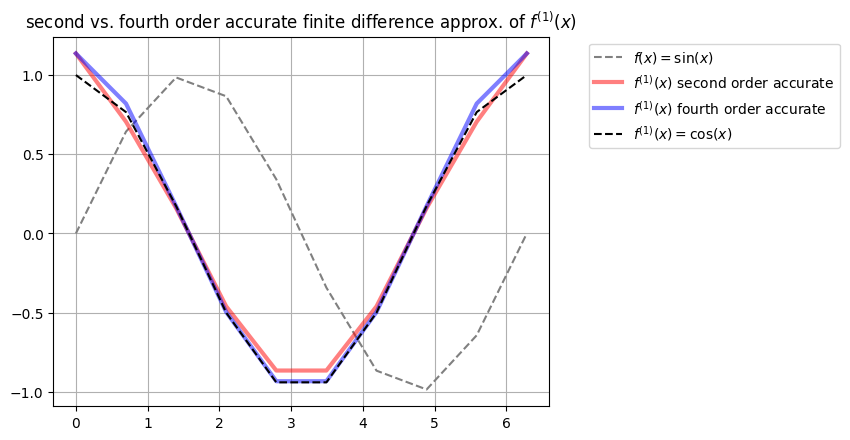

In [103]:
plt.plot(x, f, label=r'$f(x)=\sin(x)$', 
         color='gray', linestyle='dashed')
plt.plot(x, f1_second_order, label=r'$f^{(1)}(x)$ second order accurate', 
         color='red', lw=3, alpha=0.5)
plt.plot(x, f1_fourth_order, label=r'$f^{(1)}(x)$ fourth order accurate', 
         color='blue', lw=3, alpha=0.5)
plt.plot(x, f1, label=r'$f^{(1)}(x)=\cos(x)$', 
         color='black', linestyle='dashed')
plt.grid()
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1))
plt.title(r'second vs. fourth order accurate finite difference approx. of $f^{(1)}(x)$')

In [105]:
# second derivative second order accurate matrix multiplication
e = np.ones(n)
D2 = sp.sparse.diags([e, -2 * e, e], [-1, 0, 1], shape=(n, n)) / (h ** 2)
D2 = D2.tolil()
D2[0, 0:3] = np.array([1, -2, 1]) / (h ** 2)
D2[n - 1, n - 3:n] = np.array([1, -2, 1]) / (h ** 2)
f2_second_order = D2 @ f

In [107]:
# fourth order accurate second derivative matrix multiplication
e = np.ones(n)
D4 = sp.sparse.diags([-e, 16 * e, -30 * e, 16 * e, -e], [-2, -1, 0, 1, 2], shape=(n, n)) / (12 * h ** 2)
D4 = D4.tolil()
D4[0, 0:5] = np.array([45, -154, 214, -156, 41]) / (12 * h ** 2)
D4[1, 0:5] = np.array([1, -2, 1, 0, 0]) / (h ** 2)
D4[n - 1, n - 5:n] = np.array([41, -156, 214, -154, 45]) / (12 * h ** 2)
D4[n - 2, n - 5:n] = np.array([0, 0, 1, -2, 1]) / (h ** 2)
f2_fourth_order = D4 @ f

Text(0.5, 1.0, 'second vs. fourth order accurate finite difference approx. of $f^{(2)}(x)$')

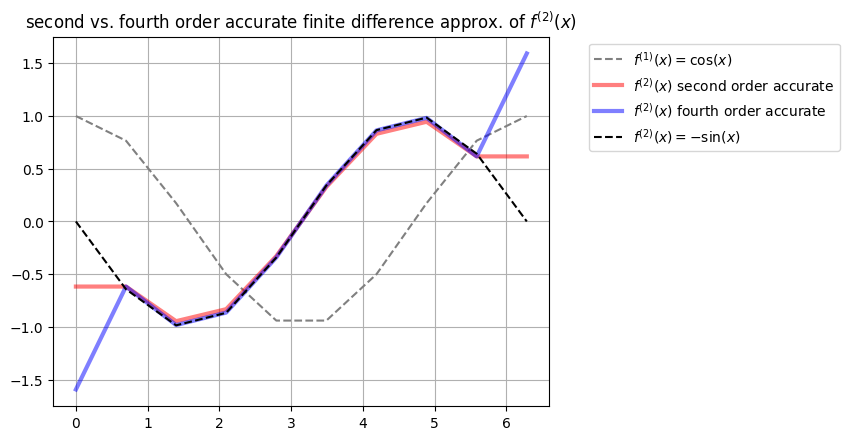

In [108]:
plt.plot(x, f1, label=r'$f^{(1)}(x)=\cos(x)$', 
         color='gray', linestyle='dashed')
plt.plot(x, f2_second_order, label=r'$f^{(2)}(x)$ second order accurate', 
         color='red', lw=3, alpha=0.5)
plt.plot(x, f2_fourth_order, label=r'$f^{(2)}(x)$ fourth order accurate',
            color='blue', lw=3, alpha=0.5)
plt.plot(x, f2, label=r'$f^{(2)}(x)=-\sin(x)$', 
         color='black', linestyle='dashed')
plt.grid()
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1))
plt.title(r'second vs. fourth order accurate finite difference approx. of $f^{(2)}(x)$')

## Problem 2